# Process Visualisation — Pipeline Order & Decision Gates

This notebook is **not** a data-analysis notebook — it doesn't load any data or fit any model.
It's a shared, versioned reference for the team.

Three diagrams:

**A. What's done in the EDA** — every step already executed in `01_eda.ipynb`, with the real
headline numbers, ending in the one decision that's still genuinely open.

**B. Baseline → compare models → tune the winner** — three steps, not three "models": fit
one fixed baseline and measure it honestly (Step 1), apply the identical setup to several
candidate model families and keep the best one (Step 2), then spend hyperparameter tuning only
on that winner (Step 3). Two decision gates between Step 2 and 3 cover feature optimization
(Lasso, PCA, correlation pruning) and imbalance handling (`class_weight`, SMOTE) — each with a
one-line why/when, and a real result from the public Kaggle/Zindi notebooks in
`00_project_plan.md` §4 as evidence, not just opinion.

**C. Inside a single cross-validation fold** — the mechanical detail behind every "5-fold CV"
mention in B: what gets refit every fold vs. what wraps around the whole loop.

## How to read these diagrams

| Shape / colour | Meaning |
|---|---|
| Green box | Already done in this project |
| Blue box | Planned / not done yet |
| Amber diamond | Decision gate — the next step depends on the answer |
| Red box | Stop / warning — a rule that must not be broken |
| Grey box | A note: the reasoning, or a cited result from a public notebook (see `00_project_plan.md` §4) |
| Dashed arrow | Feedback loop or "only if" path, not the main line |
| Dashed grey outline | A grouping — everything inside gets repeated together |

In [1]:
import textwrap

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch, Polygon

PALETTE = {
    "done": "#2E7D32",
    "next": "#33658A",
    "gate": "#F4A300",
    "stop": "#D62828",
    "note": "#E7E7E7",
}
TEXT_ON_DARK = "white"
TEXT_ON_LIGHT = "black"


def draw_box(ax, center, width, height, text, kind="next", fontsize=9.5, wrap=20, style="normal"):
    x, y = center
    color = PALETTE[kind]
    text_color = TEXT_ON_LIGHT if kind in ("gate", "note") else TEXT_ON_DARK
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.3, edgecolor="black", facecolor=color, zorder=2,
    )
    ax.add_patch(box)
    ax.text(x, y, textwrap.fill(text, wrap), ha="center", va="center",
             fontsize=fontsize, color=text_color, zorder=3, linespacing=1.3, style=style)


def draw_diamond(ax, center, width, height, text, fontsize=9.0, wrap=18):
    x, y = center
    points = [(x, y + height / 2), (x + width / 2, y), (x, y - height / 2), (x - width / 2, y)]
    diamond = Polygon(points, closed=True, linewidth=1.3, edgecolor="black",
                       facecolor=PALETTE["gate"], zorder=2)
    ax.add_patch(diamond)
    ax.text(x, y, textwrap.fill(text, wrap), ha="center", va="center",
             fontsize=fontsize, color=TEXT_ON_LIGHT, zorder=3, linespacing=1.2)


def draw_arrow(ax, start, end, label=None, dashed=False, color="black", curve=0.0,
               label_offset=(0, 0), fontsize=8.3):
    arrow = FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=13, linewidth=1.3,
        linestyle="--" if dashed else "-", color=color,
        connectionstyle=f"arc3,rad={curve}", zorder=1,
    )
    ax.add_patch(arrow)
    if label:
        mx = (start[0] + end[0]) / 2 + label_offset[0]
        my = (start[1] + end[1]) / 2 + label_offset[1]
        ax.text(mx, my, label, ha="center", va="center", fontsize=fontsize, color=color,
                 zorder=4, bbox={"boxstyle": "round,pad=0.15", "facecolor": "white",
                                  "edgecolor": "none"})


def draw_group(ax, lower_left, width, height, label):
    box = FancyBboxPatch(
        lower_left, width, height, boxstyle="round,pad=0.05,rounding_size=0.1",
        linewidth=1.3, linestyle="--", edgecolor="#666666", facecolor="none", zorder=0,
    )
    ax.add_patch(box)
    ax.text(lower_left[0] + 0.15, lower_left[1] + height - 0.25, label, ha="left", va="top",
             fontsize=9, color="#666666", style="italic", zorder=1)


def add_legend(ax, kinds, loc="lower center", ncol=2, anchor=None):
    labels = {
        "done": "Already done", "next": "Planned / next",
        "gate": "Decision gate", "stop": "Stop / warning", "note": "Reasoning / evidence note",
    }
    handles = [Patch(facecolor=PALETTE[k], edgecolor="black", label=labels[k]) for k in kinds]
    kwargs = {"bbox_to_anchor": anchor} if anchor else {}
    ax.legend(handles=handles, loc=loc, ncol=ncol, fontsize=8.5, frameon=False, **kwargs)


def new_diagram(figsize, xlim, ylim, title):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis("off")
    ax.set_title(title, fontsize=13, weight="bold", pad=14)
    return fig, ax

## A. What's done in the EDA (`01_eda.ipynb`)

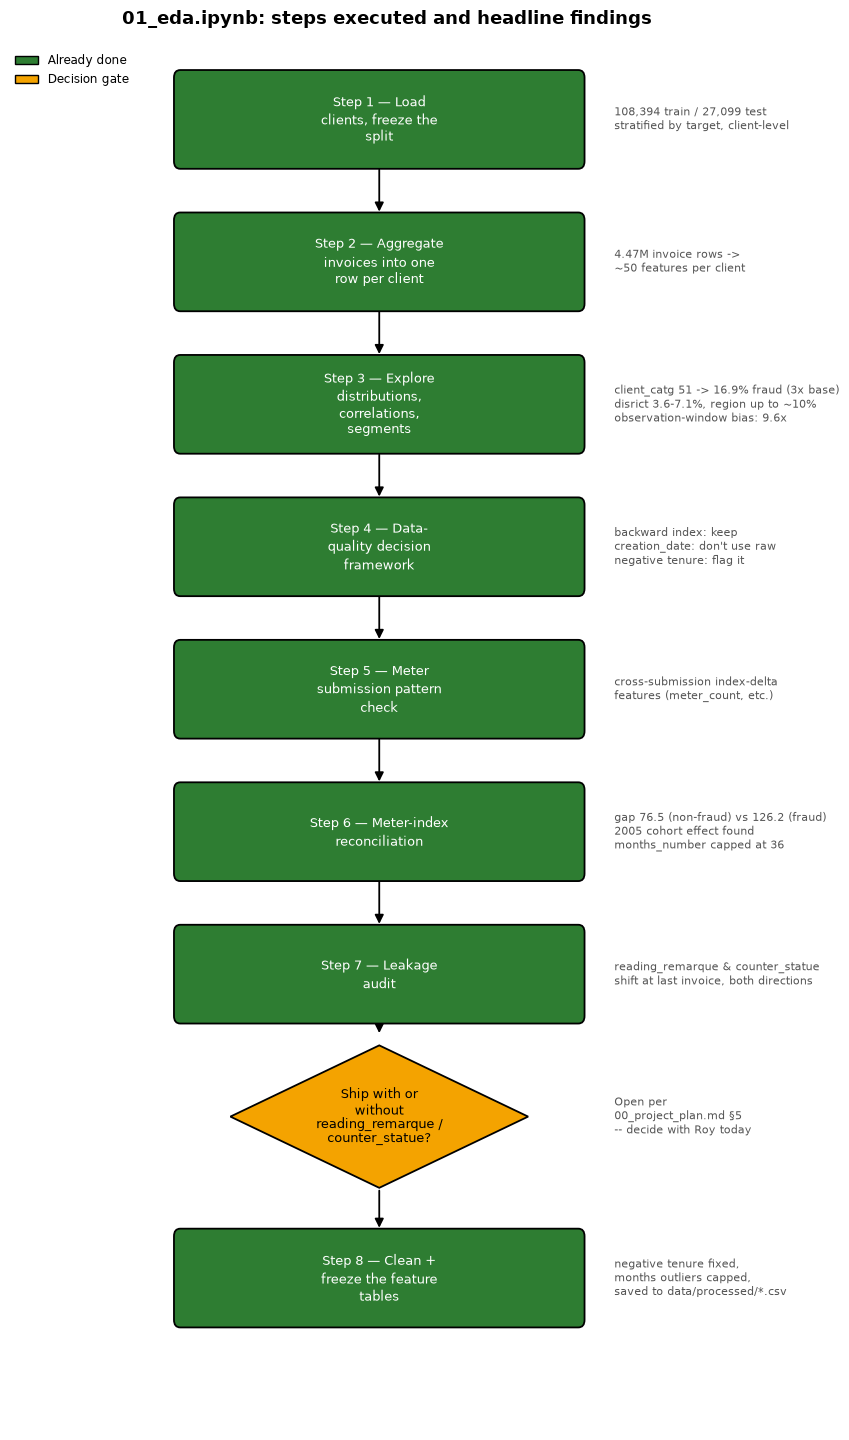

In [2]:
fig, ax = new_diagram((8.7, 14.5), (-4.6, 4.8), (-1.2, 13.4),
                       "01_eda.ipynb: steps executed and headline findings")

steps = [
    ("Step 1 — Load clients,\nfreeze the split", "108,394 train / 27,099 test\nstratified by target, client-level"),
    ("Step 2 — Aggregate invoices\ninto one row per client", "4.47M invoice rows ->\n~50 features per client"),
    ("Step 3 — Explore distributions,\ncorrelations, segments", "client_catg 51 -> 16.9% fraud (3x base)\ndisrict 3.6-7.1%, region up to ~10%\nobservation-window bias: 9.6x"),
    ("Step 4 — Data-quality\ndecision framework", "backward index: keep\ncreation_date: don't use raw\nnegative tenure: flag it"),
    ("Step 5 — Meter submission\npattern check", "cross-submission index-delta\nfeatures (meter_count, etc.)"),
    ("Step 6 — Meter-index\nreconciliation", "gap 76.5 (non-fraud) vs 126.2 (fraud)\n2005 cohort effect found\nmonths_number capped at 36"),
    ("Step 7 — Leakage audit", "reading_remarque & counter_statue\nshift at last invoice, both directions"),
]

y_positions = [12.6 - i * 1.5 for i in range(len(steps))]
for (title, note), y in zip(steps, y_positions):
    draw_box(ax, (0, y), 5.2, 1.0, title, "done")
    ax.text(3.0, y, note, fontsize=7.8, color="#555555", va="center")
    if y != y_positions[-1]:
        draw_arrow(ax, (0, y - 0.5), (0, y - 1.0))

gate_y = y_positions[-1] - 1.5
draw_arrow(ax, (0, y_positions[-1] - 0.5), (0, gate_y + 0.85))
draw_diamond(ax, (0, gate_y), 3.8, 1.5, "Ship with or without\nreading_remarque /\ncounter_statue?")
ax.text(3.0, gate_y, "Open per\n00_project_plan.md §5\n-- decide with Roy today", fontsize=7.8,
        color="#555555", va="center")

final_y = gate_y - 1.7
draw_arrow(ax, (0, gate_y - 0.75), (0, final_y + 0.5))
draw_box(ax, (0, final_y), 5.2, 1.0, "Step 8 — Clean + freeze\nthe feature tables", "done")
ax.text(3.0, final_y, "negative tenure fixed,\nmonths outliers capped,\nsaved to data/processed/*.csv",
        fontsize=7.8, color="#555555", va="center")

add_legend(ax, ["done", "gate"], loc="upper left", ncol=1, anchor=(-0.02, 1.0))
plt.tight_layout()
plt.show()

## B. Baseline -> compare models -> tune the winner

Three steps, not three "models" -- the number of candidate models tried in Step 2 doesn't
matter, what matters is the order these techniques get applied in:

1. **Baseline** — one fixed model, cross-validated for an honest measurement, no tuning.
2. **Compare** — the exact same setup (features, preprocessing, CV) applied to several
   candidate model families, so the comparison is apples-to-apples; keep whichever wins.
3. **Tune** — hyperparameter search spent only on that winner.

Two decision gates sit between Step 2 and Step 3 for the cheap checks worth doing before the
expensive tuning step: is the feature set redundant enough to prune, and is the imbalance
handling already enough. Each gate's reasoning is grounded in a real result from the Kaggle/Zindi
notebooks in `00_project_plan.md` §4, not just opinion.

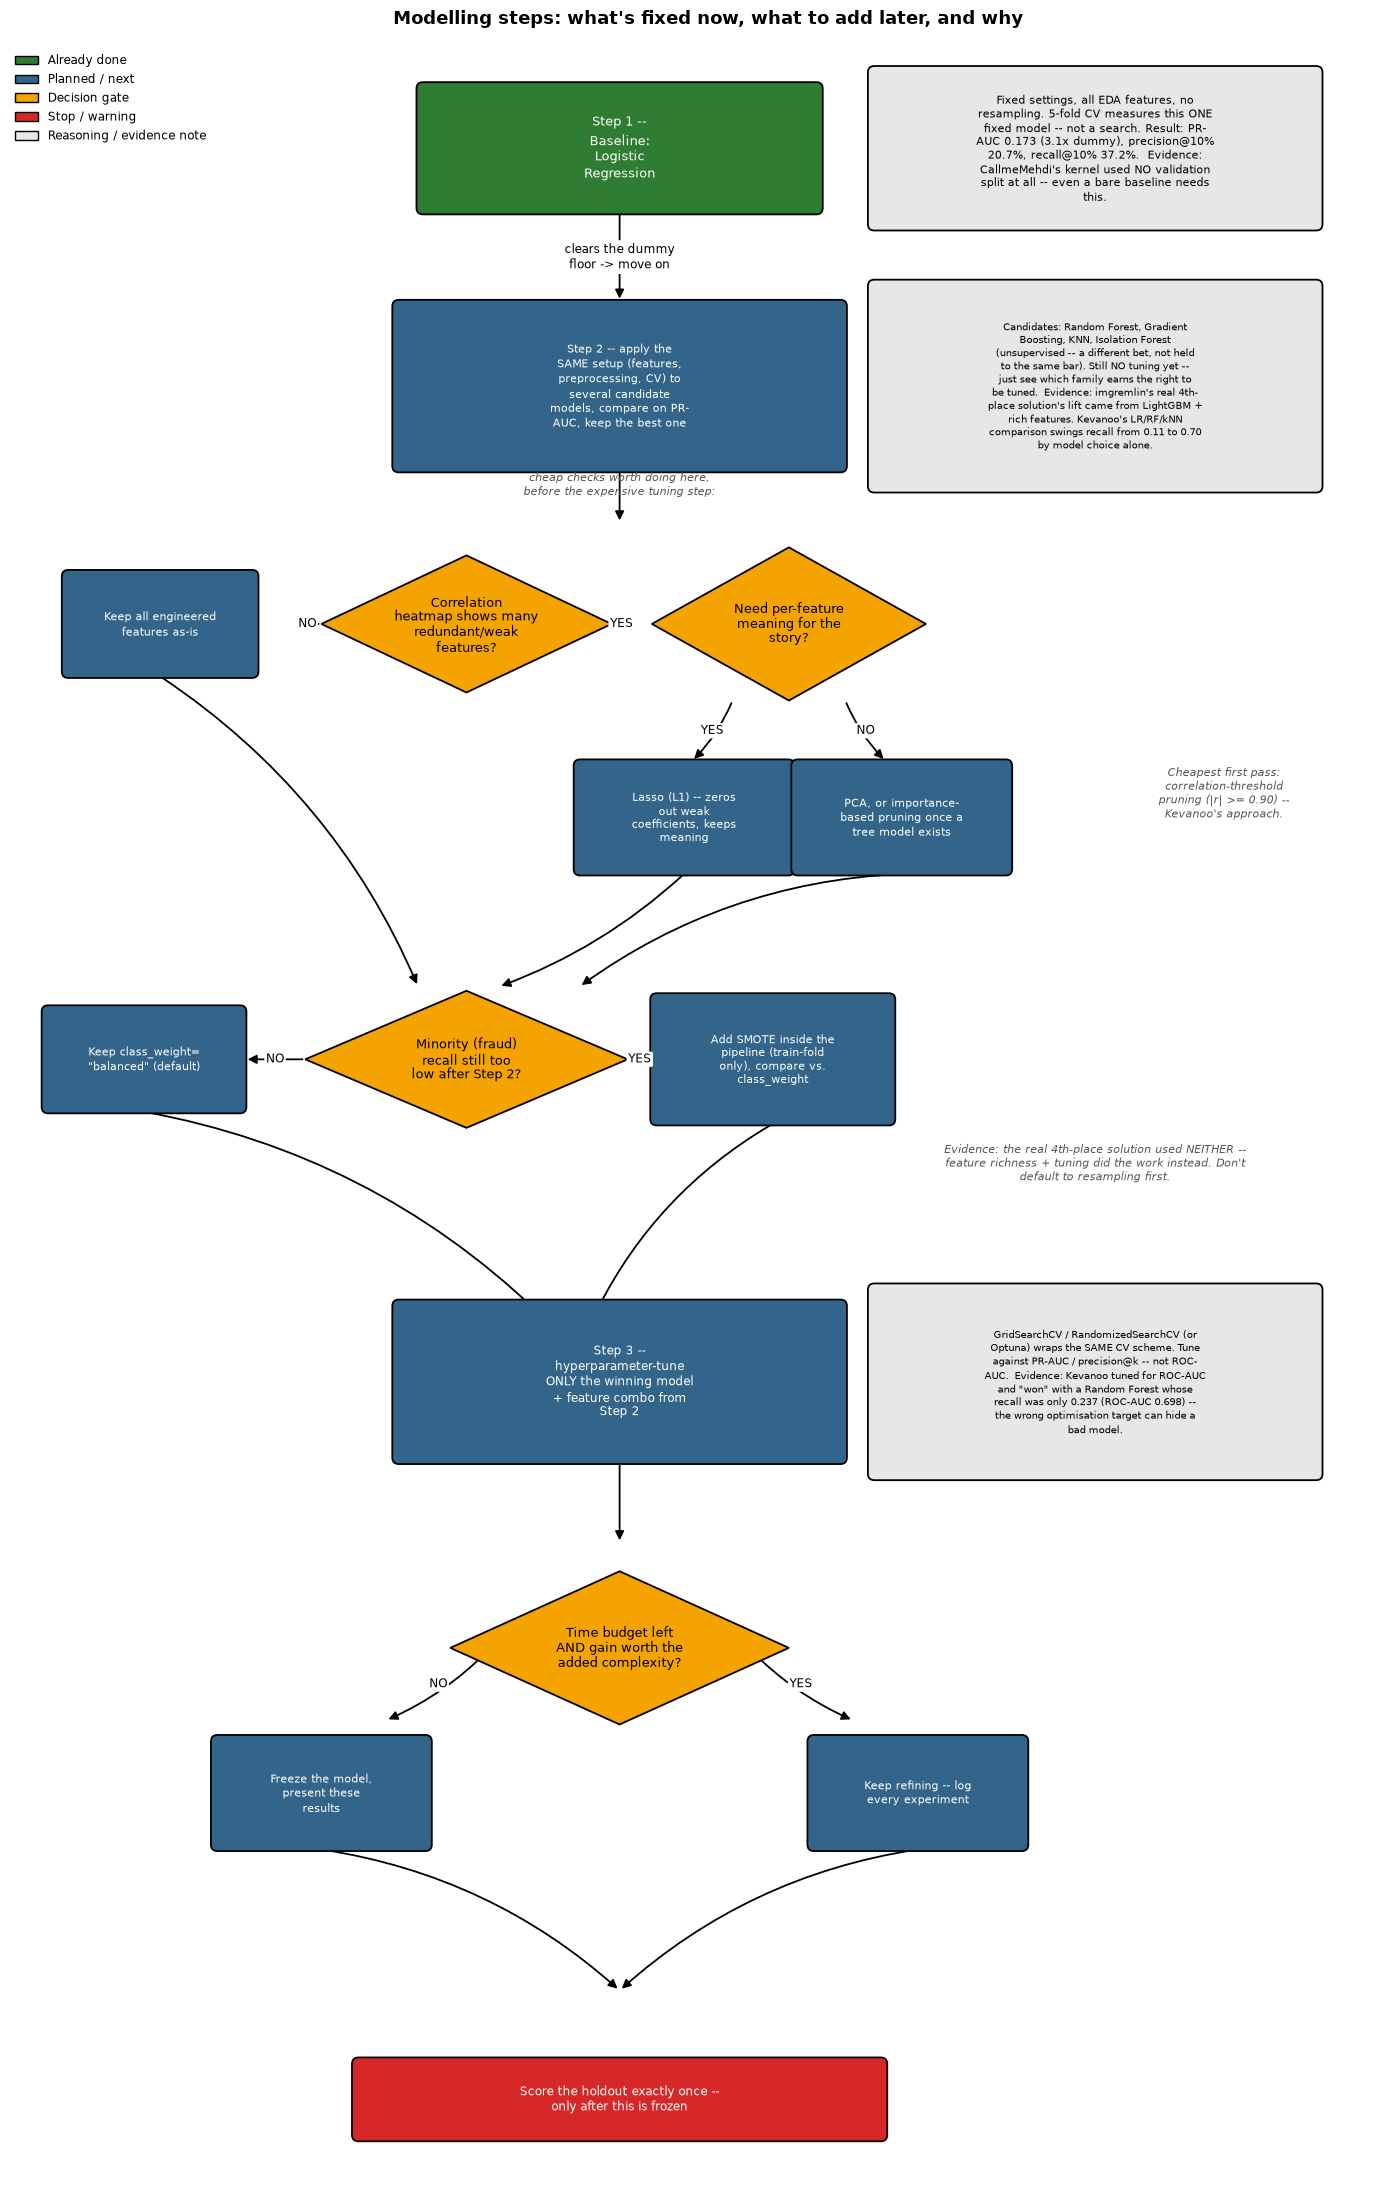

In [3]:
fig, ax = new_diagram((14, 22), (-7.8, 9.0), (-2.2, 24.3),
                       "Modelling steps: what's fixed now, what to add later, and why")

# ======================================================================= Step 1
draw_box(ax, (-0.5, 23.0), 5.0, 1.6, "Step 1 -- Baseline:\nLogistic Regression", "done", fontsize=9.5, wrap=17)
draw_box(ax, (5.4, 23.0), 5.6, 2.0,
         "Fixed settings, all EDA features, no resampling. 5-fold CV measures this ONE fixed "
         "model -- not a search. Result: PR-AUC 0.173 (3.1x dummy), precision@10% 20.7%, "
         "recall@10% 37.2%.\n\nEvidence: CallmeMehdi's kernel used NO validation split at all "
         "-- even a bare baseline needs this.",
         "note", fontsize=7.6, wrap=42)
draw_arrow(ax, (-0.5, 22.2), (-0.5, 21.1), "clears the dummy\nfloor -> move on")

# ======================================================================= Step 2
draw_box(ax, (-0.5, 20.05), 5.6, 2.1,
         "Step 2 -- apply the SAME setup (features, preprocessing, CV) to several candidate "
         "models, compare on PR-AUC, keep the best one", "next", fontsize=8.2, wrap=23)
draw_box(ax, (5.4, 20.05), 5.6, 2.6,
         "Candidates: Random Forest, Gradient Boosting, KNN, Isolation Forest (unsupervised -- "
         "a different bet, not held to the same bar). Still NO tuning yet -- just see which "
         "family earns the right to be tuned.\n\nEvidence: imgremlin's real 4th-place solution's "
         "lift came from LightGBM + rich features. Kevanoo's LR/RF/kNN comparison swings recall "
         "from 0.11 to 0.70 by model choice alone.",
         "note", fontsize=7.3, wrap=42)
draw_arrow(ax, (-0.5, 19.0), (-0.5, 18.35))
ax.text(-0.5, 18.7, "cheap checks worth doing here,\nbefore the expensive tuning step:",
        ha="center", fontsize=8.0, color="#555555", style="italic")

# ======================================================================= Gate 1: features
draw_diamond(ax, (-2.4, 17.1), 3.6, 1.7, "Correlation heatmap shows\nmany redundant/weak\nfeatures?")
draw_box(ax, (-6.2, 17.1), 2.4, 1.3, "Keep all engineered\nfeatures as-is", "next", fontsize=8)
draw_arrow(ax, (-4.2, 17.1), (-4.55, 17.1), "NO")

draw_diamond(ax, (1.6, 17.1), 3.4, 1.9, "Need per-feature\nmeaning for\nthe story?")
draw_arrow(ax, (-0.6, 17.1), (-0.35, 17.1), "YES")
draw_box(ax, (0.3, 14.7), 2.7, 1.4, "Lasso (L1) -- zeros\nout weak coefficients,\nkeeps meaning", "next", fontsize=7.6)
draw_box(ax, (3.0, 14.7), 2.7, 1.4, "PCA, or importance-\nbased pruning once a\ntree model exists", "next", fontsize=7.6)
draw_arrow(ax, (0.9, 16.15), (0.4, 15.4), "YES", curve=-0.1)
draw_arrow(ax, (2.3, 16.15), (2.8, 15.4), "NO", curve=0.1)

ax.text(7.0, 14.7, "Cheapest first pass:\ncorrelation-threshold\npruning (|r| >= 0.90) --\n"
        "Kevanoo's approach.",
        ha="center", fontsize=7.6, color="#555555", style="italic")

draw_arrow(ax, (-6.2, 16.45), (-3.0, 12.6), curve=-0.15)
draw_arrow(ax, (0.3, 14.0), (-2.0, 12.6), curve=-0.1)
draw_arrow(ax, (3.0, 14.0), (-1.0, 12.6), curve=0.15)

# ======================================================================= Gate 2: imbalance
draw_diamond(ax, (-2.4, 11.7), 4.0, 1.7, "Minority (fraud) recall\nstill too low after\nStep 2?")
draw_box(ax, (-6.4, 11.7), 2.5, 1.3, "Keep class_weight=\n\"balanced\" (default)", "next", fontsize=7.6)
draw_box(ax, (1.4, 11.7), 3.0, 1.6, "Add SMOTE inside the\npipeline (train-fold\nonly), compare vs.\nclass_weight", "next", fontsize=7.6)
draw_arrow(ax, (-4.4, 11.7), (-5.15, 11.7), "NO")
draw_arrow(ax, (-0.4, 11.7), (-0.1, 11.7), "YES")

ax.text(5.4, 10.2, "Evidence: the real 4th-place solution used NEITHER --\nfeature "
        "richness + tuning did the work instead. Don't\ndefault to resampling first.",
        ha="center", fontsize=7.6, color="#555555", style="italic")

draw_arrow(ax, (-6.4, 11.05), (-1.5, 8.55), curve=-0.15)
draw_arrow(ax, (1.4, 10.9), (-0.8, 8.55), curve=0.15)

# ======================================================================= Step 3
draw_box(ax, (-0.5, 7.7), 5.6, 2.0,
         "Step 3 -- hyperparameter-tune ONLY the winning model + feature combo from Step 2",
         "next", fontsize=8.4, wrap=23)
draw_box(ax, (5.4, 7.7), 5.6, 2.4,
         "GridSearchCV / RandomizedSearchCV (or Optuna) wraps the SAME CV scheme. Tune against "
         "PR-AUC / precision@k -- not ROC-AUC.\n\nEvidence: Kevanoo tuned for ROC-AUC and \"won\" "
         "with a Random Forest whose recall was only 0.237 (ROC-AUC 0.698) -- the wrong "
         "optimisation target can hide a bad model.",
         "note", fontsize=7.5, wrap=42)
draw_arrow(ax, (-0.5, 6.7), (-0.5, 5.7))

# ======================================================================= Final gate
draw_diamond(ax, (-0.5, 4.4), 4.2, 1.9, "Time budget left AND\ngain worth the added\ncomplexity?")
draw_box(ax, (-4.2, 2.6), 2.7, 1.4, "Freeze the model,\npresent these results", "next", fontsize=8)
draw_box(ax, (3.2, 2.6), 2.7, 1.4, "Keep refining --\nlog every experiment", "next", fontsize=8)
draw_arrow(ax, (-2.1, 4.4), (-3.4, 3.5), "NO", curve=-0.1)
draw_arrow(ax, (1.1, 4.4), (2.4, 3.5), "YES", curve=0.1)
draw_arrow(ax, (-4.2, 1.9), (-0.5, 0.15), curve=-0.15)
draw_arrow(ax, (3.2, 1.9), (-0.5, 0.15), curve=0.15)
draw_box(ax, (-0.5, -1.2), 6.6, 1.0, "Score the holdout exactly once -- only after this is frozen",
         "stop", fontsize=8.3, wrap=34)

add_legend(ax, ["done", "next", "gate", "stop", "note"], loc="upper left", ncol=1,
           anchor=(-0.02, 1.0))
plt.tight_layout()
plt.show()

## C. Inside a single cross-validation fold

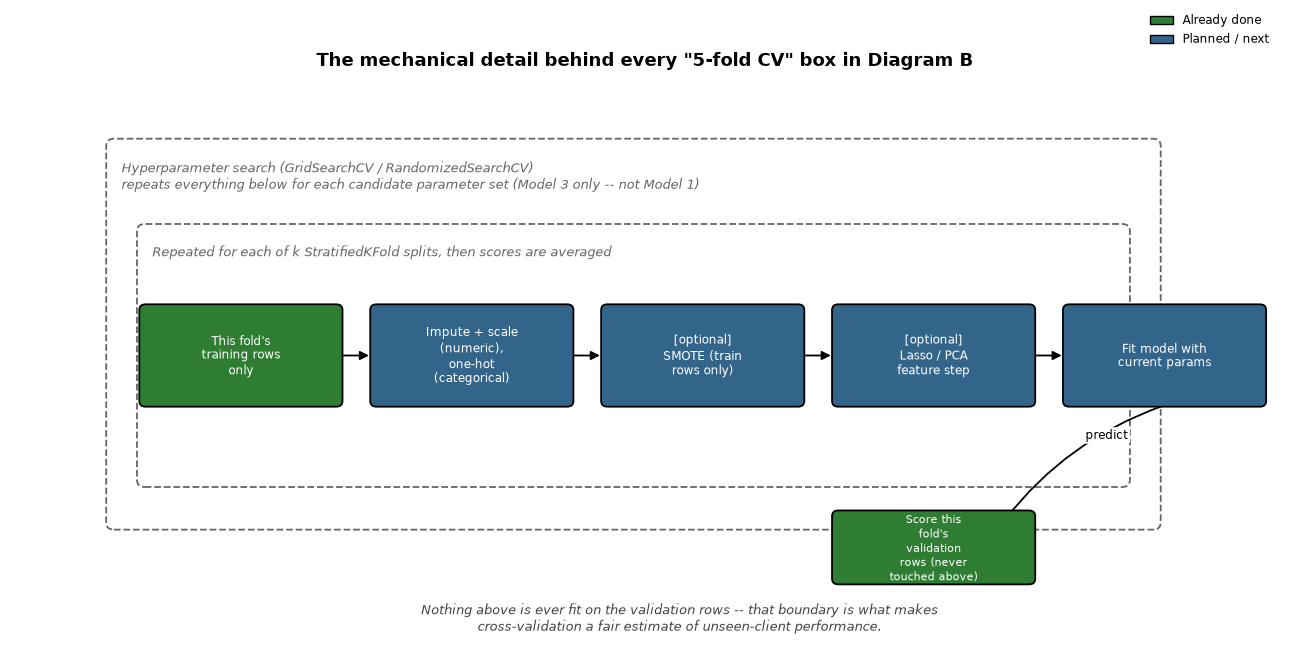

In [4]:
fig, ax = new_diagram((13, 6.5), (-1, 15.5), (-1.2, 6.5),
                       "The mechanical detail behind every \"5-fold CV\" box in Diagram B")

draw_group(ax, (0.3, 0.3), 13.6, 5.4, "Hyperparameter search (GridSearchCV / RandomizedSearchCV)\nrepeats everything below for each candidate parameter set (Model 3 only -- not Model 1)")
draw_group(ax, (0.7, 0.9), 12.8, 3.6, "Repeated for each of k StratifiedKFold splits, then scores are averaged")

draw_box(ax, (2.0, 2.7), 2.6, 1.4, "This fold's\ntraining rows\nonly", "done", fontsize=8.5, wrap=14)
draw_box(ax, (5.0, 2.7), 2.6, 1.4, "Impute + scale\n(numeric),\none-hot (categorical)", "next", fontsize=8.5, wrap=14)
draw_box(ax, (8.0, 2.7), 2.6, 1.4, "[optional]\nSMOTE\n(train rows only)", "next", fontsize=8.5, wrap=14)
draw_box(ax, (11.0, 2.7), 2.6, 1.4, "[optional]\nLasso / PCA\nfeature step", "next", fontsize=8.5, wrap=14)
draw_box(ax, (14.0, 2.7), 2.6, 1.4, "Fit model with\ncurrent params", "next", fontsize=8.5, wrap=14)

draw_arrow(ax, (3.3, 2.7), (3.7, 2.7))
draw_arrow(ax, (6.3, 2.7), (6.7, 2.7))
draw_arrow(ax, (9.3, 2.7), (9.7, 2.7))
draw_arrow(ax, (12.3, 2.7), (12.7, 2.7))

draw_box(ax, (11.0, 0.0), 2.6, 1.0, "Score this fold's\nvalidation rows\n(never touched above)", "done", fontsize=8, wrap=14)
draw_arrow(ax, (14.0, 2.0), (11.9, 0.35), curve=0.15,
           label="predict", label_offset=(0.3, 0.4))

ax.text(7.7, -1.0,
        "Nothing above is ever fit on the validation rows -- that boundary is what makes\n"
        "cross-validation a fair estimate of unseen-client performance.",
        ha="center", va="center", fontsize=9, style="italic", color="#444444")

add_legend(ax, ["done", "next"], loc="upper right", ncol=1, anchor=(1.0, 1.15))
plt.tight_layout()
plt.show()

## Cheat sheet: techniques at a glance

| Technique | What it does | When to reach for it | Cost / risk | Library | Evidence from `00_project_plan.md` §4 |
|---|---|---|---|---|---|
| Cross-validation (`StratifiedKFold`) | Estimates how a choice generalises, over several train/validation splits | Always — even for the plain baseline | Cheap; just refits the pipeline k times | `sklearn.model_selection` | CallmeMehdi's kernel skipped this entirely (imported `StratifiedKFold`, never used it) — the cautionary example |
| Hyperparameter tuning (`GridSearchCV` / `RandomizedSearchCV` / Optuna) | Searches model settings for the best CV score | Only once model family + features are settled | Most expensive step; scales with grid size × folds | `sklearn.model_selection` | imgremlin used Optuna + 5-fold CV + early stopping, and checked local CV matched the leaderboard before trusting it |
| Lasso (L1 logistic regression) | Shrinks weak coefficients to exactly zero | Many correlated/weak features, interpretability still matters | Cheap — one extra fit | `sklearn.linear_model` | — |
| Correlation-threshold pruning | Drops one of any feature pair with \|r\| ≥ 0.90 | Cheapest first pass at redundant features — no model refit loop | Very cheap | plain `pandas`/`numpy` | Kevanoo's approach |
| PCA | Compresses correlated numeric features into fewer components | Same redundancy situation, per-feature meaning not needed | Loses interpretability; fit inside each CV fold only | `sklearn.decomposition` | — |
| Feature-importance pruning | Uses a fitted tree model's importances to drop weak features | After a tree ensemble exists | Needs a model fit first | `sklearn.ensemble`/`sklearn.feature_selection` | imgremlin's approach, after LightGBM |
| `class_weight="balanced"` | Reweights the loss so the rare class matters more | First, cheapest response to the ~5.6% imbalance | Free | built into most `sklearn` classifiers | Used in our own baseline |
| SMOTE | Synthesises new minority-class training rows | Only if `class_weight` alone isn't enough | Must sit inside `imblearn.pipeline.Pipeline`, training fold only | `imbalanced-learn` | Kevanoo used it; imgremlin's actual 4th-place solution used **neither** SMOTE nor `class_weight` — feature richness + tuning did the work |
| Tree ensembles (Random Forest / Gradient Boosting) | Capture non-linear effects & interactions | Right after the linear baseline, before heavy tuning | Slower to fit/tune, less directly interpretable | `sklearn.ensemble` | Kevanoo's RF hit ROC-AUC 0.698 but recall only 0.237 — tune against the right metric |
| Threshold / top-k tuning | Converts a probability into a yes/no decision at actual capacity | After model + features are frozen | Cheap — a cutoff on scores already computed | plain `numpy`/`pandas` | Kevanoo scored at the default 0.5 cutoff — a likely cause of RF's low recall |

## Where we are right now

- **Diagram A**: all of `01_eda.ipynb` is done through Step 8. The one thing still genuinely
  open is whether `reading_remarque`/`counter_statue` ship as features at all (`00_project_plan.md`
  §5) — worth deciding explicitly today rather than defaulting silently either way.
- **Diagram B, Step 1 (baseline)**: done. PR-AUC 0.173 (3.1x the dummy floor), precision@10%
  20.7%, recall@10% 37.2% — 2 of 3 KPI targets already clear; PR-AUC's 0.20 goal is not yet met.
- **Diagram B, Step 2 (compare models)**: not started. No model family besides logistic
  regression has been tried yet, so per this map that's the recommended next step — before
  tuning, before Lasso/PCA, before SMOTE.
- **Feature optimization / imbalance toolboxes**: available whenever they're needed, not
  required yet — nothing so far shows the ~50 features are redundant enough to need Lasso/PCA,
  and `class_weight="balanced"` hasn't been shown insufficient.
- **Holdout**: still untouched, exactly as it should be at this stage.